<a href="https://colab.research.google.com/github/aniket-alt/CMPE-258-Deep-Learning/blob/main/Assignment%20-%204/2_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Data Augmentation Across Modalities
## Comprehensive Guide to Augmentation for Images, Text, Time Series, Tabular Data, and Audio

---

**Author:** Aniket Patole  
**Course:** CMPE 258 - Deep Learning  
**Assignment:** Advanced Customizations in Deep Learning and Neural Networks

---

### Objective

Data augmentation is a powerful technique to artificially expand training datasets by creating modified versions of existing data. This notebook demonstrates augmentation techniques across multiple data modalities:

1. **Image Augmentation** - Using KerasCV, Albumentations, and TensorFlow
2. **Text Augmentation** - Using nlpaug library
3. **Time Series Augmentation** - Custom techniques for sequential data
4. **Tabular Data Augmentation** - SMOTE and other techniques
5. **Audio Augmentation** - Using audiomentations and librosa

### Why Data Augmentation?

- **Reduces overfitting** by exposing the model to more variations
- **Improves generalization** to unseen data
- **Addresses class imbalance** in datasets
- **Cost-effective** alternative to collecting more data

---

## Part A: Installation and Setup

We need to install several specialized libraries for different modalities. Each library is optimized for its specific data type:

- **keras-cv**: Advanced image augmentation integrated with Keras
- **albumentations**: Fast image augmentation library
- **nlpaug**: Text augmentation with multiple techniques
- **audiomentations**: Audio data augmentation
- **imbalanced-learn**: SMOTE for tabular data
- **librosa**: Audio processing

In [1]:
# Install required libraries
!pip install -q keras-cv albumentations nlpaug audiomentations librosa imbalanced-learn
!pip install -q transformers  # For advanced text augmentation

print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 29.8 MB/s eta 0:00:00
All libraries installed successfully!


### Import All Required Libraries

We import libraries organized by modality. This makes it easy to understand which tools are used for which type of data.

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Image augmentation
import keras_cv
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from PIL import Image

# Text augmentation
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.sentence as nas

# Audio augmentation
import librosa
import librosa.display
import audiomentations as AA

# Tabular augmentation
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# PyTorch for some examples
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras CV version: {keras_cv.__version__}")
print("All imports successful!")

TensorFlow version: 2.19.0
Keras CV version: 0.9.0
All imports successful!


---

# Section 1: Image Data Augmentation

Image augmentation is the most common form of data augmentation. We'll explore three popular approaches:

1. **TensorFlow/Keras built-in layers** - Simple and integrated
2. **KerasCV** - Advanced augmentations with cutting-edge techniques
3. **Albumentations** - Fast and highly customizable

Common image augmentations include:
- Geometric: rotation, flipping, scaling, cropping
- Color: brightness, contrast, saturation, hue
- Advanced: CutOut, MixUp, CutMix, RandAugment

---

### Loading Sample Images for Demonstration

We'll use the CIFAR-10 dataset for image augmentation demonstrations. It contains 32x32 color images across 10 classes.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training images shape: (50000, 32, 32, 3)
Image dimensions: (32, 32, 3)


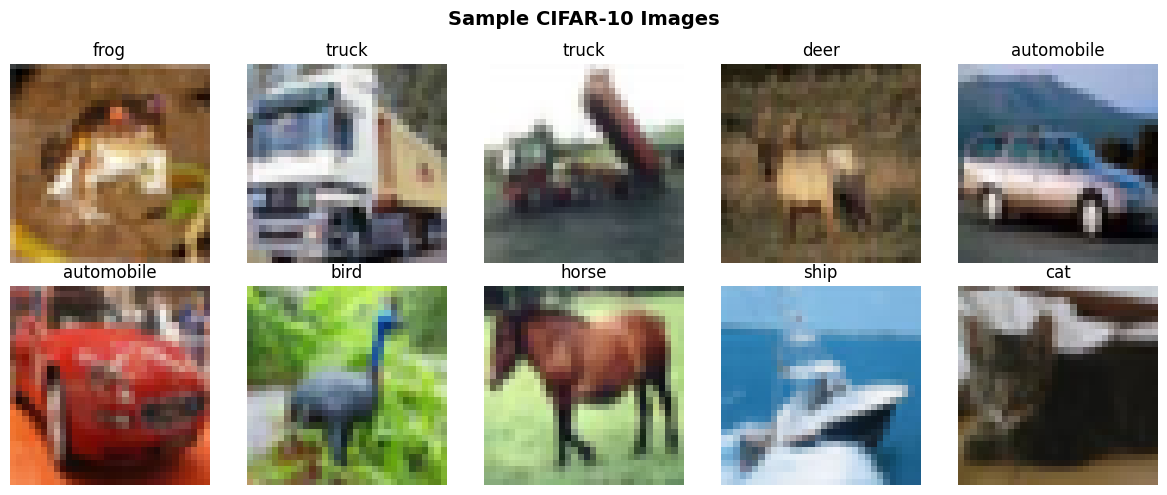

In [3]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Training images shape: {X_train.shape}")
print(f"Image dimensions: {X_train.shape[1:]}")

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i])
    ax.set_title(cifar_classes[y_train[i][0]])
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.1 TensorFlow/Keras Built-in Augmentation Layers

Keras provides preprocessing layers that can be included directly in the model. These layers are active only during training and automatically disabled during inference.

**Advantages:**
- Seamless integration with Keras models
- GPU-accelerated augmentation
- No additional preprocessing pipeline needed

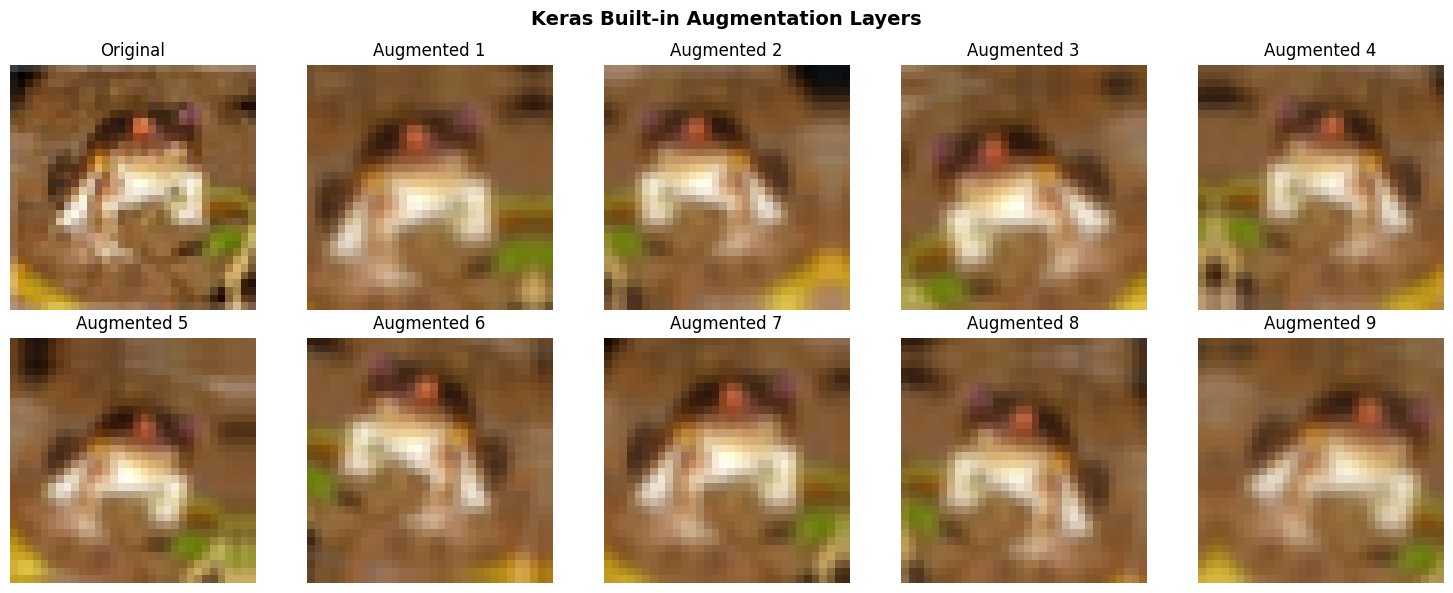

In [4]:
# Create a Keras augmentation pipeline using Sequential layers
keras_augmentation = keras.Sequential([
    # Random horizontal flip
    layers.RandomFlip("horizontal"),

    # Random rotation up to 15 degrees
    layers.RandomRotation(0.05),

    # Random zoom
    layers.RandomZoom(0.1),

    # Random translation
    layers.RandomTranslation(0.1, 0.1),

    # Random contrast adjustment
    layers.RandomContrast(0.2),
], name='keras_augmentation')

# Demonstrate augmentation on a single image
# Convert to tensor for KerasCV compatibility
sample_image = tf.convert_to_tensor(X_train[0:1], dtype=tf.float32)  # Shape: (1, 32, 32, 3)

# Apply augmentation multiple times
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_image[0].numpy())
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    augmented = keras_augmentation(sample_image, training=True)
    ax.imshow(augmented[0].numpy())
    ax.set_title(f'Augmented {i+1}')
    ax.axis('off')

plt.suptitle('Keras Built-in Augmentation Layers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.2 KerasCV Advanced Augmentation

KerasCV provides cutting-edge augmentation techniques that have proven effective in recent research:

- **RandAugment**: Automatically searches for the best augmentation policy
- **CutMix**: Cuts and pastes patches between images
- **MixUp**: Creates convex combinations of image pairs
- **CutOut/RandomErasing**: Randomly erases rectangular regions

These techniques often provide significant improvements over basic augmentations.

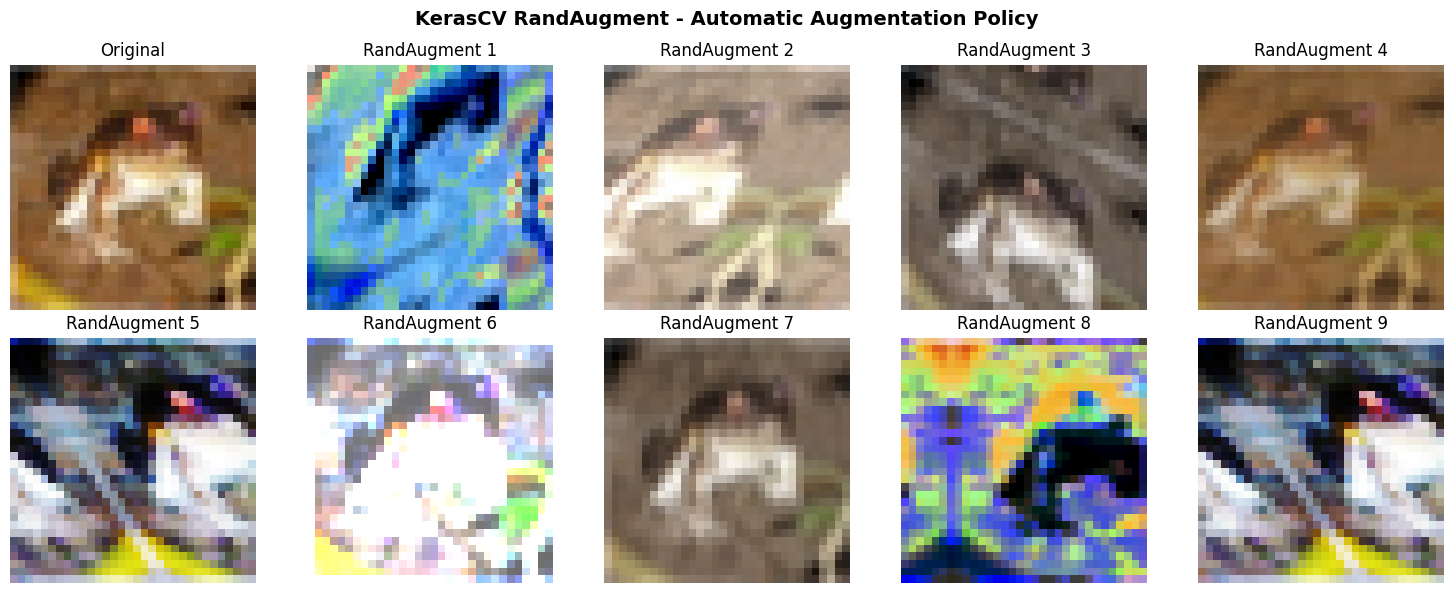

In [5]:
# KerasCV RandAugment - automatically applies a series of augmentations
rand_augment = keras_cv.layers.RandAugment(
    value_range=(0, 1),
    augmentations_per_image=3,  # Number of augmentations per image
    magnitude=0.5,  # Strength of augmentations
)

# Demonstrate RandAugment
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_image[0].numpy())
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    augmented = rand_augment(sample_image)
    # Clip values to valid range
    augmented = tf.clip_by_value(augmented, 0, 1)
    ax.imshow(augmented[0].numpy())
    ax.set_title(f'RandAugment {i+1}')
    ax.axis('off')

plt.suptitle('KerasCV RandAugment - Automatic Augmentation Policy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### KerasCV CutMix and MixUp

**CutMix** cuts a patch from one image and pastes it onto another, mixing labels proportionally.

**MixUp** creates a weighted average of two images and their labels.

Both techniques help the model learn smoother decision boundaries.

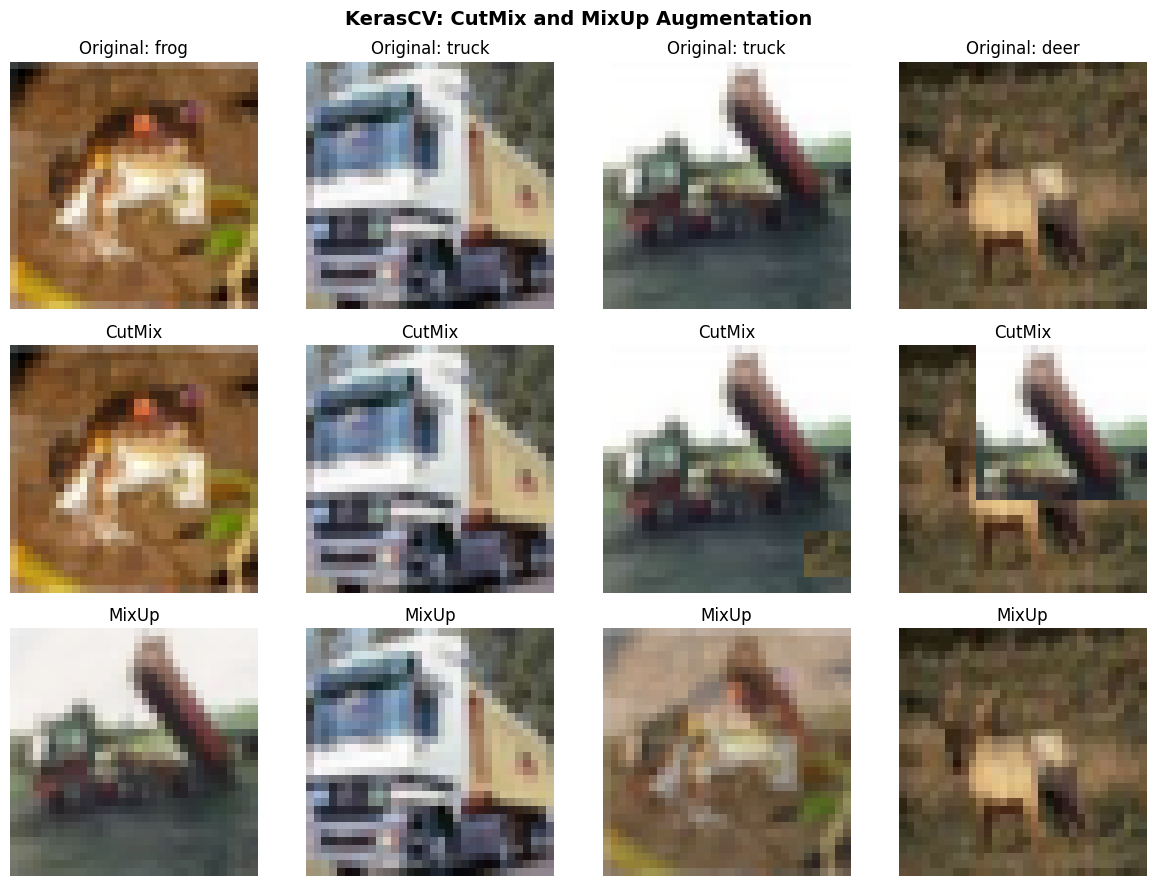

In [6]:
# Prepare batch for CutMix/MixUp demonstration
batch_size = 4

# IMPORTANT: Convert numpy arrays to TensorFlow tensors
# KerasCV layers require tensors, not numpy arrays
sample_batch = tf.convert_to_tensor(X_train[:batch_size], dtype=tf.float32)
sample_labels = tf.one_hot(y_train[:batch_size].flatten(), 10)  # One-hot encode

# CutMix - cuts patches from one image and pastes onto another
cutmix = keras_cv.layers.CutMix()
cutmix_result = cutmix({'images': sample_batch, 'labels': sample_labels})
cutmix_images = cutmix_result['images']
cutmix_labels = cutmix_result['labels']

# MixUp - blends two images together
mixup = keras_cv.layers.MixUp()
mixup_result = mixup({'images': sample_batch, 'labels': sample_labels})
mixup_images = mixup_result['images']
mixup_labels = mixup_result['labels']

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# Original images
for i in range(4):
    axes[0, i].imshow(sample_batch[i].numpy())
    axes[0, i].set_title(f'Original: {cifar_classes[y_train[i][0]]}')
    axes[0, i].axis('off')

# CutMix images
for i in range(4):
    axes[1, i].imshow(tf.clip_by_value(cutmix_images[i], 0, 1).numpy())
    axes[1, i].set_title('CutMix')
    axes[1, i].axis('off')

# MixUp images
for i in range(4):
    axes[2, i].imshow(tf.clip_by_value(mixup_images[i], 0, 1).numpy())
    axes[2, i].set_title('MixUp')
    axes[2, i].axis('off')

plt.suptitle('KerasCV: CutMix and MixUp Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### KerasCV Random Cutout (Erasing)

RandomCutout/RandomErasing randomly removes rectangular regions from images, forcing the model to focus on multiple parts of the image rather than relying on specific features.

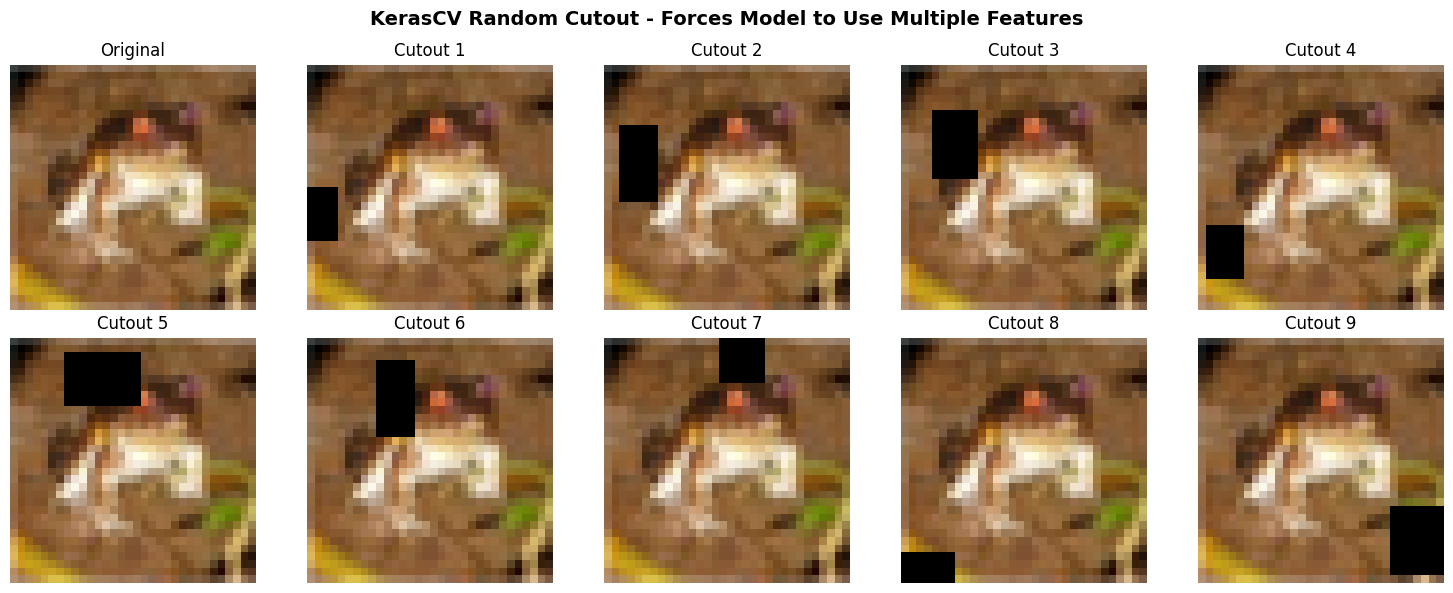

In [7]:
# Random Erasing / Cutout
random_cutout = keras_cv.layers.RandomCutout(
    height_factor=(0.1, 0.3),
    width_factor=(0.1, 0.3),
)

# Demonstrate Cutout
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_image[0].numpy())
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    augmented = random_cutout(sample_image)
    ax.imshow(tf.clip_by_value(augmented[0], 0, 1).numpy())
    ax.set_title(f'Cutout {i+1}')
    ax.axis('off')

plt.suptitle('KerasCV Random Cutout - Forces Model to Use Multiple Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.3 Albumentations Library

Albumentations is a fast image augmentation library that's particularly popular in computer vision competitions. It offers:

- **Speed**: Optimized for performance
- **Flexibility**: Highly customizable pipelines
- **Variety**: Wide range of augmentation techniques
- **Integration**: Works with both PyTorch and TensorFlow

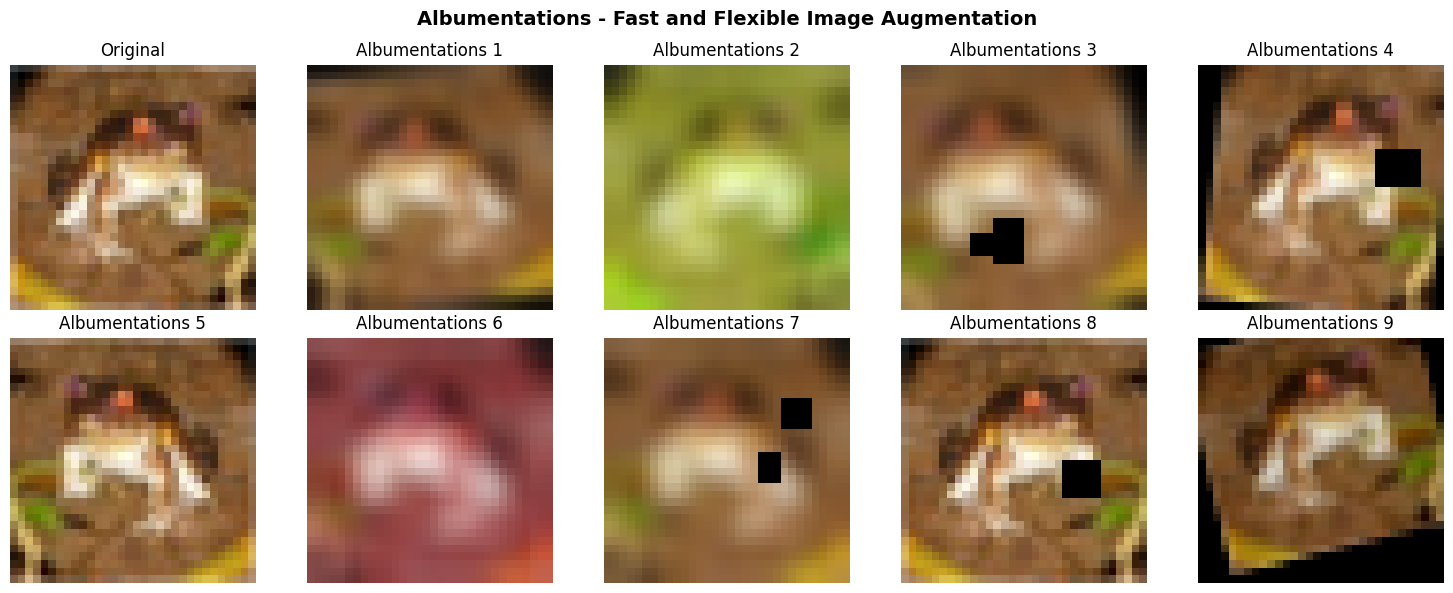

In [8]:
# Define an Albumentations augmentation pipeline
albumentations_transform = A.Compose([
    # Geometric transformations
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),

    # Color transformations
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1),
    ], p=0.5),

    # Blur and noise
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1),
        A.GaussNoise(var_limit=(10, 50), p=1),
    ], p=0.3),

    # Advanced techniques
    A.CoarseDropout(max_holes=8, max_height=4, max_width=4, p=0.3),
])

# Apply to sample image (Albumentations expects uint8)
sample_uint8 = (X_train[0] * 255).astype(np.uint8)

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_uint8)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    augmented = albumentations_transform(image=sample_uint8)['image']
    ax.imshow(augmented)
    ax.set_title(f'Albumentations {i+1}')
    ax.axis('off')

plt.suptitle('Albumentations - Fast and Flexible Image Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Albumentations: Advanced Weather and Distortion Effects

Albumentations provides realistic augmentations like weather effects (rain, fog, snow) and optical distortions. These are particularly useful for training robust models for real-world applications.

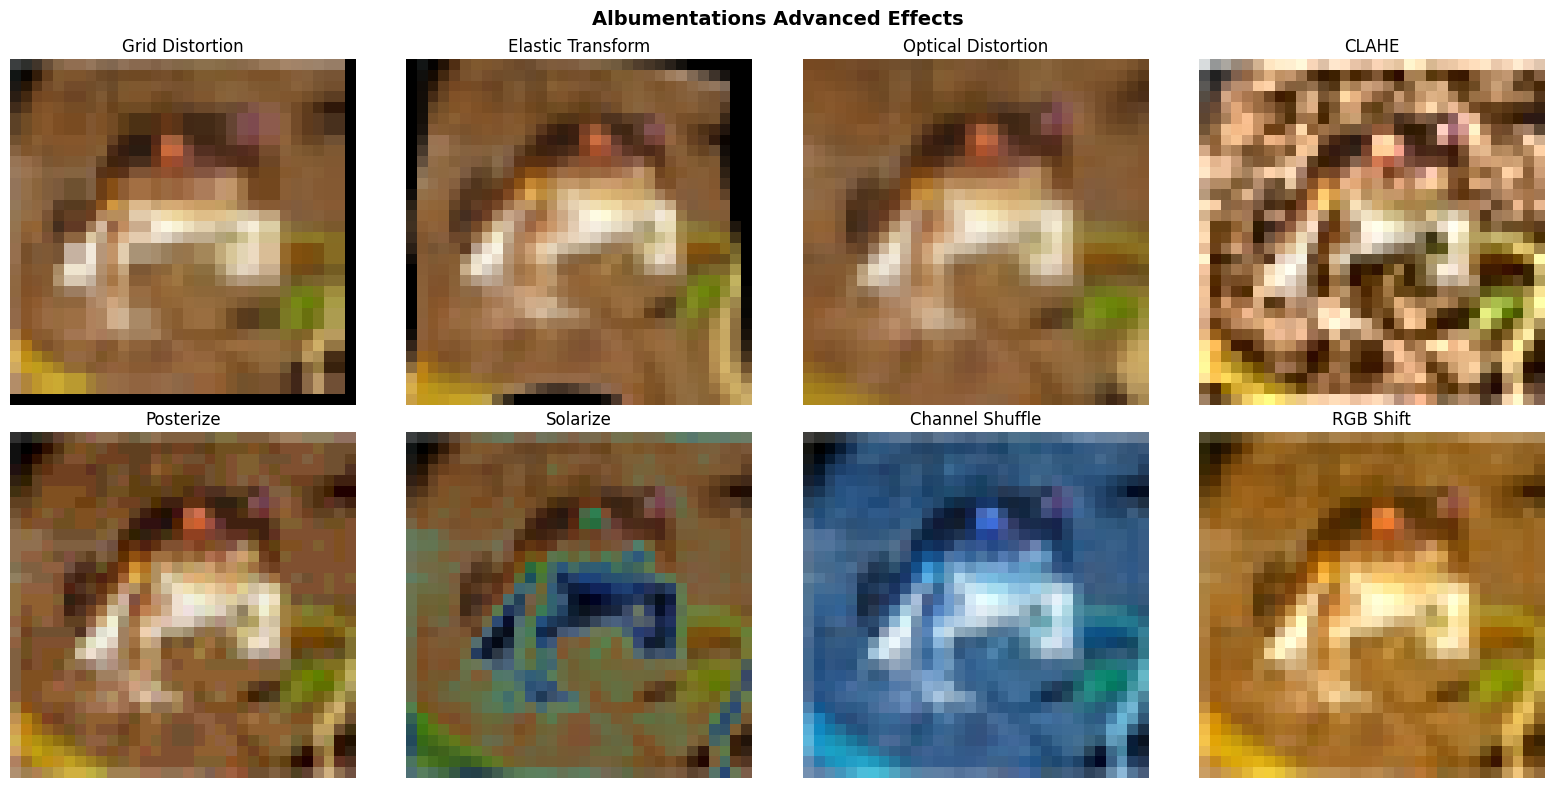

In [9]:
# Advanced Albumentations effects
advanced_transforms = {
    'Grid Distortion': A.GridDistortion(p=1),
    'Elastic Transform': A.ElasticTransform(alpha=50, sigma=5, p=1),
    'Optical Distortion': A.OpticalDistortion(distort_limit=0.3, p=1),
    'CLAHE': A.CLAHE(clip_limit=4.0, p=1),
    'Posterize': A.Posterize(num_bits=4, p=1),
    'Solarize': A.Solarize(threshold=128, p=1),
    'Channel Shuffle': A.ChannelShuffle(p=1),
    'RGB Shift': A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=1),
}

# Visualize each transform
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (name, transform) in enumerate(advanced_transforms.items()):
    augmented = transform(image=sample_uint8)['image']
    axes[i].imshow(augmented)
    axes[i].set_title(name)
    axes[i].axis('off')

plt.suptitle('Albumentations Advanced Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4 A/B Test: Augmentation Impact on Model Performance

Let's train two CNN models on CIFAR-10:
1. **Without augmentation** (baseline)
2. **With augmentation** (using KerasCV)

We'll compare their performance to quantify the benefits of data augmentation.

In [10]:
def create_cnn_model():
    """
    Create a simple CNN for CIFAR-10 classification.
    """
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Create augmentation layer for training
augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

# Use subset for faster training
X_train_subset = X_train[:10000]
y_train_subset = y_train[:10000]
X_val = X_train[45000:50000]
y_val = y_train[45000:50000]

print("Training data shape:", X_train_subset.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (10000, 32, 32, 3)
Validation data shape: (5000, 32, 32, 3)


### Training Model WITHOUT Augmentation

First, we train the baseline model without any data augmentation to establish a reference point.

In [11]:
# Train without augmentation
print("Training CNN WITHOUT augmentation...")
print("=" * 50)

model_no_aug = create_cnn_model()

history_no_aug = model_no_aug.fit(
    X_train_subset, y_train_subset,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluate
test_loss_no_aug, test_acc_no_aug = model_no_aug.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy (No Augmentation): {test_acc_no_aug:.4f}")

Training CNN WITHOUT augmentation...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.3456 - loss: 2.0748 - val_accuracy: 0.1166 - val_loss: 3.0768
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4876 - loss: 1.4940 - val_accuracy: 0.2194 - val_loss: 2.5127
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5556 - loss: 1.2523 - val_accuracy: 0.4500 - val_loss: 1.5477
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6138 - loss: 1.0877 - val_accuracy: 0.6190 - val_loss: 1.0801
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6500 - loss: 0.9787 - val_accuracy: 0.5920 - val_loss: 1.2006
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6851 - loss: 0.8865 - val_accuracy: 0.5940 - val_loss: 1.2060
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7178 - loss: 0.7945 - val_accuracy: 0.6484 - val_loss: 1.0305
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 

### Training Model WITH Augmentation

Now we train the same model but with data augmentation applied during training.

In [12]:
# Train with augmentation
print("Training CNN WITH augmentation...")
print("=" * 50)

# Create model with augmentation layer
model_with_aug = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    augmentation_layer,  # Add augmentation at the beginning
])

# Add the rest of the CNN
cnn_layers = create_cnn_model()
for layer in cnn_layers.layers:
    model_with_aug.add(layer)

model_with_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_with_aug = model_with_aug.fit(
    X_train_subset, y_train_subset,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluate
test_loss_with_aug, test_acc_with_aug = model_with_aug.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy (With Augmentation): {test_acc_with_aug:.4f}")

Training CNN WITH augmentation...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.2910 - loss: 2.2820 - val_accuracy: 0.1008 - val_loss: 3.5344
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3688 - loss: 1.8351 - val_accuracy: 0.2008 - val_loss: 2.6757
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4152 - loss: 1.6546 - val_accuracy: 0.4366 - val_loss: 1.5559
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4504 - loss: 1.5358 - val_accuracy: 0.4672 - val_loss: 1.4563
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4721 - loss: 1.4612 - val_accuracy: 0.4336 - val_loss: 1.7803
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4850 - loss: 1.4197 - val_accuracy: 0.3852 - val_loss: 1.9617
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5083 - loss: 1.3679 - val_accuracy: 0.4944 - val_loss: 1.5558
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accurac

### Comparing Results: With vs Without Augmentation

Let's visualize the training dynamics and compare the final performance of both models.

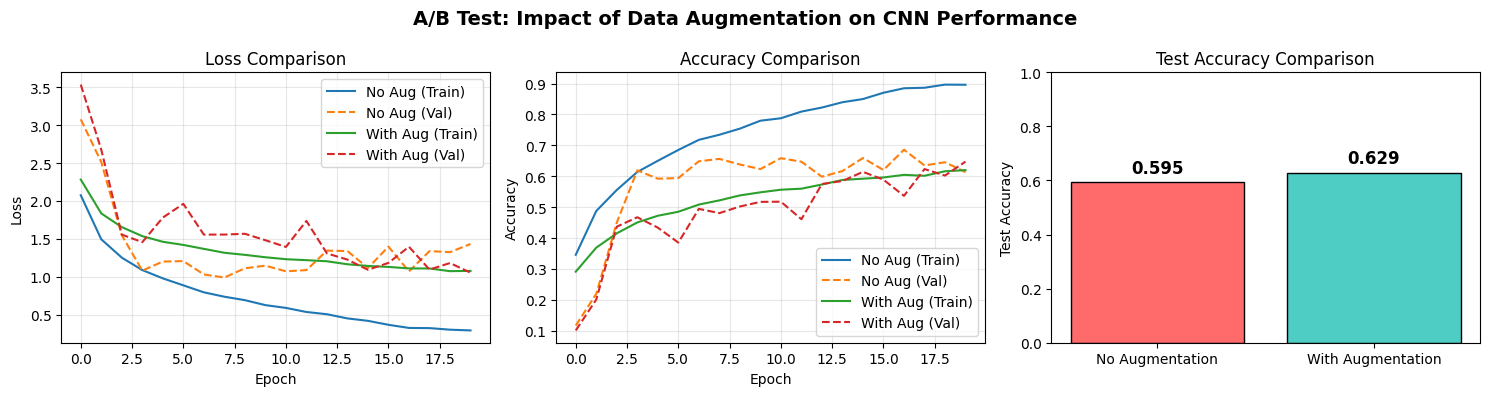


IMAGE AUGMENTATION A/B TEST RESULTS
Without Augmentation: 0.5946
With Augmentation:    0.6293
Improvement:          +3.47%


In [13]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss comparison
axes[0].plot(history_no_aug.history['loss'], label='No Aug (Train)', linestyle='-')
axes[0].plot(history_no_aug.history['val_loss'], label='No Aug (Val)', linestyle='--')
axes[0].plot(history_with_aug.history['loss'], label='With Aug (Train)', linestyle='-')
axes[0].plot(history_with_aug.history['val_loss'], label='With Aug (Val)', linestyle='--')
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_no_aug.history['accuracy'], label='No Aug (Train)', linestyle='-')
axes[1].plot(history_no_aug.history['val_accuracy'], label='No Aug (Val)', linestyle='--')
axes[1].plot(history_with_aug.history['accuracy'], label='With Aug (Train)', linestyle='-')
axes[1].plot(history_with_aug.history['val_accuracy'], label='With Aug (Val)', linestyle='--')
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Bar chart of test accuracy
methods = ['No Augmentation', 'With Augmentation']
accuracies = [test_acc_no_aug, test_acc_with_aug]
colors = ['#FF6B6B', '#4ECDC4']
bars = axes[2].bar(methods, accuracies, color=colors, edgecolor='black')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Test Accuracy Comparison')
axes[2].set_ylim([0, 1])

# Add value labels
for bar, acc in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('A/B Test: Impact of Data Augmentation on CNN Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
improvement = (test_acc_with_aug - test_acc_no_aug) * 100
print(f"\n{'='*50}")
print(f"IMAGE AUGMENTATION A/B TEST RESULTS")
print(f"{'='*50}")
print(f"Without Augmentation: {test_acc_no_aug:.4f}")
print(f"With Augmentation:    {test_acc_with_aug:.4f}")
print(f"Improvement:          {improvement:+.2f}%")
print(f"{'='*50}")

---

# Section 2: Text Data Augmentation

Text augmentation is essential for NLP tasks, especially when labeled data is limited. We use the **nlpaug** library which provides various augmentation techniques:

1. **Character-level**: Typos, keyboard errors, OCR simulation
2. **Word-level**: Synonym replacement, random insertion/deletion/swap
3. **Sentence-level**: Back translation, paraphrasing

---

### Sample Text for Augmentation

We'll use a few sample sentences to demonstrate various text augmentation techniques.

In [14]:
# Sample texts for augmentation
sample_texts = [
    "Deep learning models require large amounts of training data to achieve good performance.",
    "Data augmentation helps improve model generalization by creating synthetic training examples.",
    "Natural language processing has made significant advances in recent years.",
]

print("Original Texts:")
print("=" * 80)
for i, text in enumerate(sample_texts):
    print(f"{i+1}. {text}")

Original Texts:
1. Deep learning models require large amounts of training data to achieve good performance.
2. Data augmentation helps improve model generalization by creating synthetic training examples.
3. Natural language processing has made significant advances in recent years.


## 2.1 Character-Level Augmentation

Character-level augmentation simulates real-world text variations like typos and OCR errors. This helps models become robust to noisy input.

In [15]:
# Character-level augmenters
print("\nCHARACTER-LEVEL AUGMENTATION")
print("=" * 80)

# Keyboard error augmenter (simulates typing mistakes)
keyboard_aug = nac.KeyboardAug(aug_char_p=0.1, aug_word_p=0.1)

# Random character augmenter (insert, delete, substitute)
random_char_aug = nac.RandomCharAug(action='substitute', aug_char_p=0.1)

# OCR augmenter (simulates OCR errors like 0/O confusion)
ocr_aug = nac.OcrAug(aug_char_p=0.1)

sample = sample_texts[0]
print(f"\nOriginal: {sample}")
print(f"\nKeyboard errors: {keyboard_aug.augment(sample)[0]}")
print(f"\nRandom char sub: {random_char_aug.augment(sample)[0]}")
print(f"\nOCR simulation: {ocr_aug.augment(sample)[0]}")


CHARACTER-LEVEL AUGMENTATION

Original: Deep learning models require large amounts of training data to achieve good performance.

Keyboard errors: Deep learning models require large a<ounts of training data to achievR good performance.

Random char sub: Deep learning models require lxrge amou)ts of Hraining data to achieve go@d per7ormInce.

OCR simulation: Oeep learning mude1s require large amoont8 of tkainin9 data t0 achieve good performance.


## 2.2 Word-Level Augmentation

Word-level augmentation modifies words while trying to preserve meaning:

- **Synonym replacement**: Replace words with their synonyms
- **Random insertion**: Insert random similar words
- **Random swap**: Swap positions of random words
- **Random deletion**: Randomly delete words

In [17]:
# Download required NLTK resources for text augmentation
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK resources downloaded successfully!


In [18]:
print("\nWORD-LEVEL AUGMENTATION")
print("=" * 80)

# Synonym augmenter using WordNet
synonym_aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.3)

# Random word augmenter - swap
swap_aug = naw.RandomWordAug(action='swap', aug_p=0.3)

# Random word augmenter - delete
delete_aug = naw.RandomWordAug(action='delete', aug_p=0.2)

# Random word augmenter - crop (remove from start/end)
crop_aug = naw.RandomWordAug(action='crop', aug_p=0.2)

sample = sample_texts[0]
print(f"\nOriginal:          {sample}")
print(f"\nSynonym replace:   {synonym_aug.augment(sample)[0]}")
print(f"\nWord swap:         {swap_aug.augment(sample)[0]}")
print(f"\nWord deletion:     {delete_aug.augment(sample)[0]}")
print(f"\nWord crop:         {crop_aug.augment(sample)[0]}")


WORD-LEVEL AUGMENTATION

Original:          Deep learning models require large amounts of training data to achieve good performance.

Synonym replace:   Oceanic abyss erudition models command large amounts of training information to achieve good execution.

Word swap:         Learning deep models require amounts large of to training achieve data good performance.

Word deletion:     Deep models require large amounts of training data to performance.

Word crop:         Deep learning models require large amounts to achieve good performance.


### Word Embedding-Based Augmentation

We can use word embeddings (Word2Vec, GloVe) to find semantically similar words for replacement. This produces more natural-sounding augmentations.

In [19]:
print("\nEMBEDDING-BASED AUGMENTATION")
print("=" * 80)

# Word2Vec-based augmentation (uses pre-trained word vectors)
# Note: First run may download the model
try:
    word2vec_aug = naw.WordEmbsAug(
        model_type='word2vec',
        model_path=None,  # Uses default Google News vectors
        action='substitute',
        aug_p=0.3
    )
    sample = sample_texts[1]
    print(f"\nOriginal:  {sample}")
    print(f"\nWord2Vec:  {word2vec_aug.augment(sample)[0]}")
except Exception as e:
    print(f"Word2Vec augmentation skipped (model download required): {e}")

# Contextual word embeddings using BERT
print("\nLoading BERT contextual augmenter (may take a moment)...")
try:
    bert_aug = naw.ContextualWordEmbsAug(
        model_path='bert-base-uncased',
        action='substitute',
        aug_p=0.3,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    sample = sample_texts[2]
    print(f"\nOriginal:  {sample}")
    print(f"\nBERT aug:  {bert_aug.augment(sample)[0]}")
except Exception as e:
    print(f"BERT augmentation skipped: {e}")


EMBEDDING-BASED AUGMENTATION
Word2Vec augmentation skipped (model download required): Missed gensim library. Install transfomers by `pip install gensim`

Loading BERT contextual augmenter (may take a moment)...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT augmentation skipped: BertTokenizer has no attribute _convert_token_to_id


## 2.3 Creating a Text Augmentation Pipeline

For practical use, we can combine multiple augmentation techniques into a single pipeline that randomly applies different augmentations to create diverse training examples.

In [20]:
import random

def augment_text_pipeline(text, n_augments=5):
    """
    Apply multiple random augmentations to generate diverse text variations.

    Args:
        text: Input text to augment
        n_augments: Number of augmented versions to create

    Returns:
        List of augmented texts
    """
    # Define augmenters
    augmenters = [
        naw.SynonymAug(aug_src='wordnet', aug_p=0.2),
        naw.RandomWordAug(action='swap', aug_p=0.2),
        naw.RandomWordAug(action='delete', aug_p=0.15),
        nac.KeyboardAug(aug_char_p=0.05, aug_word_p=0.1),
        nac.RandomCharAug(action='insert', aug_char_p=0.05),
    ]

    augmented_texts = [text]  # Include original

    for _ in range(n_augments):
        # Randomly select 1-2 augmenters to apply
        selected = random.sample(augmenters, k=random.randint(1, 2))
        aug_text = text
        for aug in selected:
            aug_text = aug.augment(aug_text)[0]
        augmented_texts.append(aug_text)

    return augmented_texts


# Demonstrate pipeline
print("TEXT AUGMENTATION PIPELINE")
print("=" * 80)

sample = "Machine learning algorithms can automatically learn patterns from data."
augmented = augment_text_pipeline(sample, n_augments=5)

print(f"\nOriginal: {sample}\n")
print("Augmented versions:")
for i, text in enumerate(augmented[1:], 1):
    print(f"  {i}. {text}")

TEXT AUGMENTATION PIPELINE

Original: Machine learning algorithms can automatically learn patterns from data.

Augmented versions:
  1. Learning algorithms can automatically learn patterns from.
  2. Machine learninH can algorithms learn automatically patterns from data.
  3. Machine learning algorithms can automaticallHy learn paxtterns hfrom data.
  4. Learning machine algorithms can automatically learn pattedns data from.
  5. Machine algorithms learning can learn automatically paFterns from data.


---

# Section 3: Time Series Data Augmentation

Time series augmentation is crucial for tasks like signal processing, forecasting, and activity recognition. Unlike images, we need to preserve temporal patterns while adding variations.

**Common techniques:**
- **Jittering**: Adding random noise
- **Scaling**: Multiplying by random factors
- **Time warping**: Stretching/compressing time axis
- **Window cropping**: Extracting random subsequences
- **Permutation**: Shuffling segments while preserving local patterns

---

### Generate Sample Time Series Data

We create synthetic time series data representing different patterns (sinusoidal, trend, noisy) for demonstration.

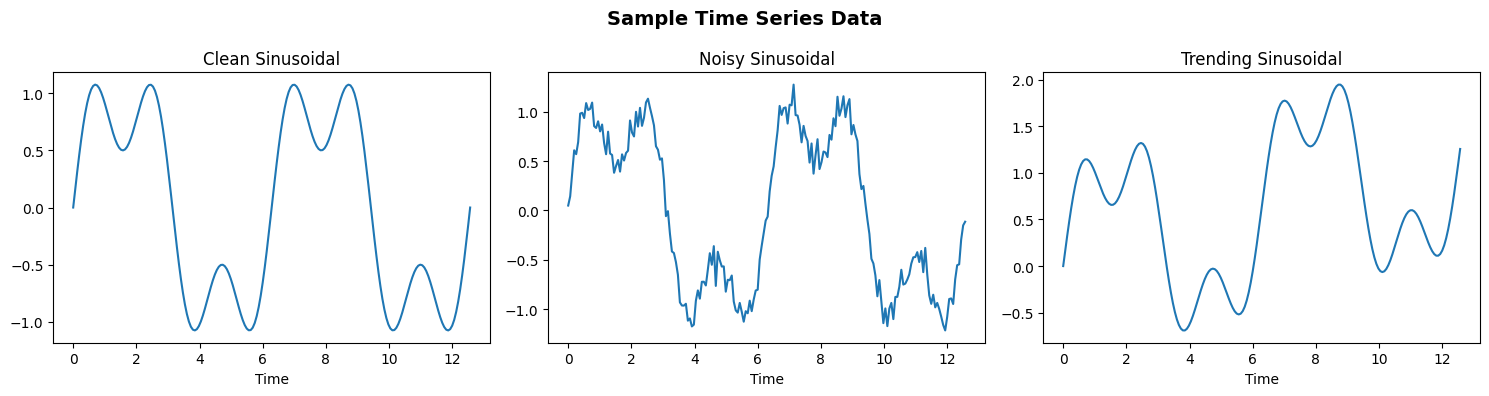

In [21]:
# Generate sample time series
np.random.seed(42)
t = np.linspace(0, 4 * np.pi, 200)  # Time points

# Create different time series patterns
sine_wave = np.sin(t) + 0.5 * np.sin(3 * t)
noisy_sine = sine_wave + 0.1 * np.random.randn(len(t))
trending_sine = sine_wave + 0.1 * t

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, sine_wave)
axes[0].set_title('Clean Sinusoidal')
axes[0].set_xlabel('Time')

axes[1].plot(t, noisy_sine)
axes[1].set_title('Noisy Sinusoidal')
axes[1].set_xlabel('Time')

axes[2].plot(t, trending_sine)
axes[2].set_title('Trending Sinusoidal')
axes[2].set_xlabel('Time')

plt.suptitle('Sample Time Series Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.1 Time Series Augmentation Functions

We implement custom augmentation functions for time series data. Each function creates a variation of the original series while preserving its essential characteristics.

In [22]:
def jitter(x, sigma=0.03):
    """
    Add random Gaussian noise to time series.

    Args:
        x: Input time series
        sigma: Standard deviation of noise
    """
    return x + np.random.normal(0, sigma, x.shape)


def scaling(x, sigma=0.1):
    """
    Scale time series by a random factor.

    Args:
        x: Input time series
        sigma: Standard deviation of scaling factor
    """
    factor = np.random.normal(1, sigma)
    return x * factor


def magnitude_warp(x, sigma=0.2, knot=4):
    """
    Warp the magnitude of time series using smooth random curves.

    Args:
        x: Input time series
        sigma: Standard deviation of warping
        knot: Number of knot points for cubic spline
    """
    from scipy.interpolate import CubicSpline

    orig_steps = np.arange(len(x))
    random_warps = np.random.normal(1, sigma, knot + 2)
    warp_steps = np.linspace(0, len(x) - 1, num=knot + 2)

    spline = CubicSpline(warp_steps, random_warps)
    warper = spline(orig_steps)

    return x * warper


def time_warp(x, sigma=0.2, knot=4):
    """
    Warp the time axis of time series using smooth random curves.
    This stretches/compresses different parts of the series.

    Args:
        x: Input time series
        sigma: Standard deviation of warping
        knot: Number of knot points for cubic spline
    """
    from scipy.interpolate import CubicSpline

    orig_steps = np.arange(len(x))
    random_warps = np.random.normal(1, sigma, knot + 2)
    warp_steps = np.linspace(0, len(x) - 1, num=knot + 2)

    spline = CubicSpline(warp_steps, random_warps)
    time_warper = np.cumsum(spline(orig_steps))
    time_warper = (time_warper - time_warper.min()) / (time_warper.max() - time_warper.min()) * (len(x) - 1)

    # Interpolate to get warped series
    return np.interp(orig_steps, time_warper, x)


def window_slice(x, reduce_ratio=0.9):
    """
    Extract a random slice from the time series and resize to original length.

    Args:
        x: Input time series
        reduce_ratio: Ratio of original length to keep
    """
    target_len = int(len(x) * reduce_ratio)
    start = np.random.randint(0, len(x) - target_len)
    sliced = x[start:start + target_len]

    # Resize back to original length
    return np.interp(
        np.linspace(0, target_len - 1, len(x)),
        np.arange(target_len),
        sliced
    )


def permutation(x, n_segments=4):
    """
    Randomly permute segments of the time series.

    Args:
        x: Input time series
        n_segments: Number of segments to create
    """
    segment_len = len(x) // n_segments
    segments = [x[i*segment_len:(i+1)*segment_len] for i in range(n_segments)]
    np.random.shuffle(segments)
    return np.concatenate(segments)


print("Time series augmentation functions defined!")

Time series augmentation functions defined!


### Visualizing Time Series Augmentations

Let's apply each augmentation to our sample time series and visualize the results. This helps understand how each technique modifies the original data.

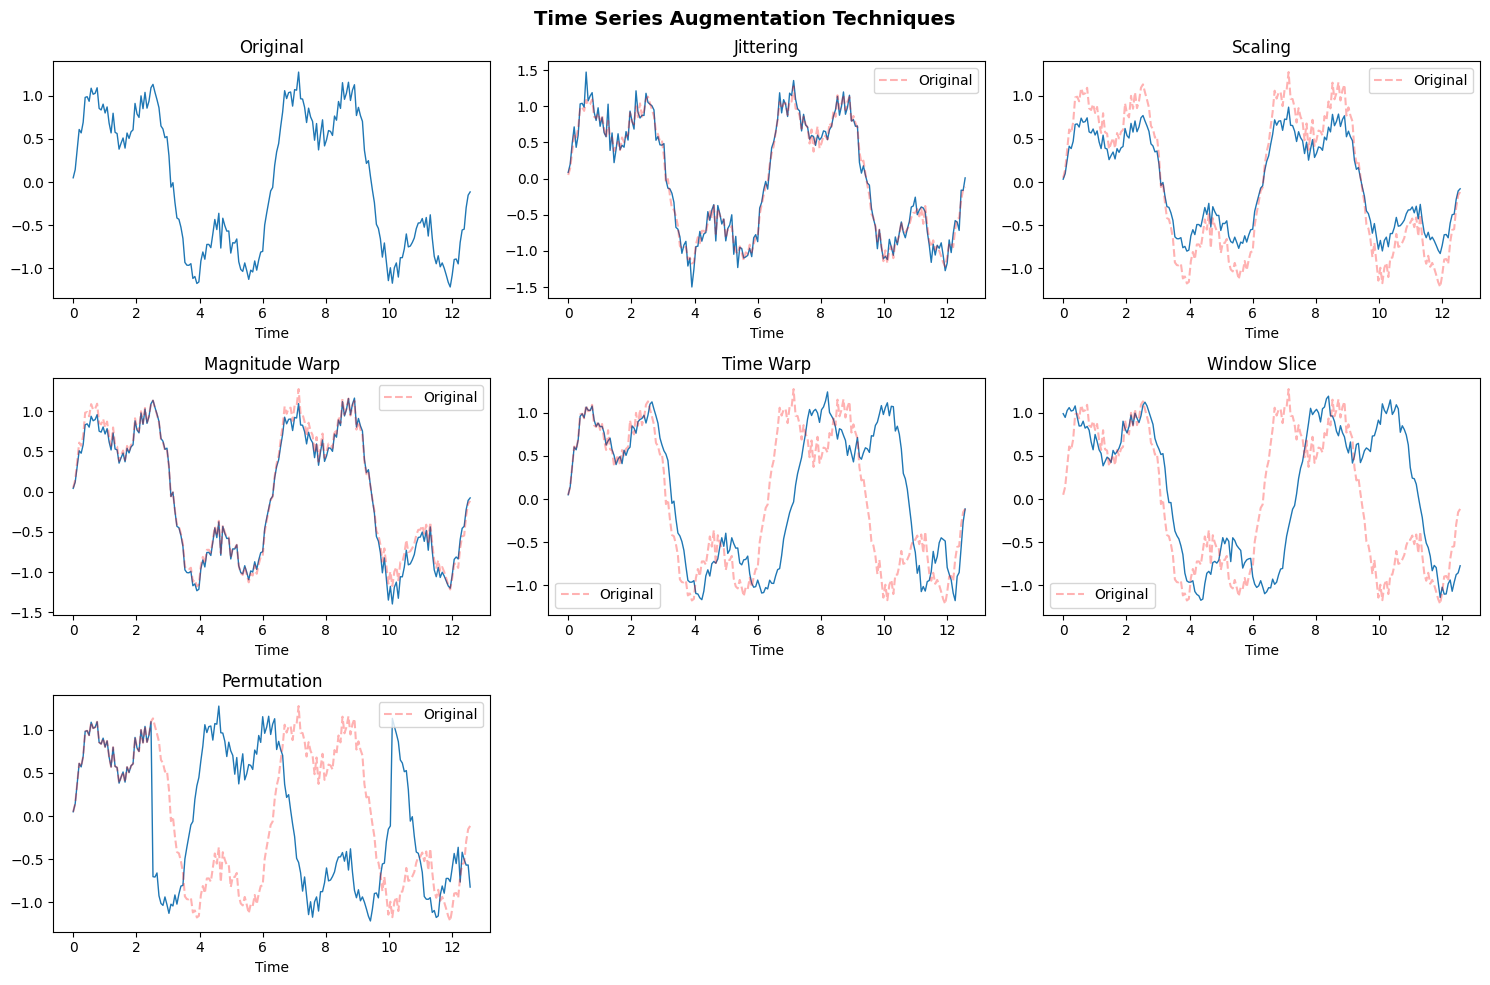

In [23]:
# Apply augmentations to noisy sine wave
original = noisy_sine.copy()

augmentations = {
    'Original': original,
    'Jittering': jitter(original, sigma=0.1),
    'Scaling': scaling(original, sigma=0.2),
    'Magnitude Warp': magnitude_warp(original, sigma=0.3),
    'Time Warp': time_warp(original, sigma=0.3),
    'Window Slice': window_slice(original, reduce_ratio=0.8),
    'Permutation': permutation(original, n_segments=5),
}

# Visualize
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, series) in enumerate(augmentations.items()):
    if i < len(axes):
        axes[i].plot(t[:len(series)], series, linewidth=1)
        if name != 'Original':
            axes[i].plot(t, original, 'r--', alpha=0.3, label='Original')
        axes[i].set_title(name)
        axes[i].set_xlabel('Time')
        if name != 'Original':
            axes[i].legend()

# Hide extra subplots
for i in range(len(augmentations), len(axes)):
    axes[i].axis('off')

plt.suptitle('Time Series Augmentation Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Section 4: Tabular Data Augmentation

Tabular data augmentation is essential for handling **class imbalance** - a common problem where some classes have far fewer examples than others. This can cause models to be biased toward majority classes.

**Techniques covered:**
- **SMOTE** (Synthetic Minority Over-sampling Technique): Generates synthetic samples by interpolating between existing minority class samples
- **ADASYN** (Adaptive Synthetic Sampling): Similar to SMOTE but generates more samples for harder-to-learn examples
- **Borderline-SMOTE**: Focuses on samples near the decision boundary

---

### Create Imbalanced Dataset

We create a synthetic imbalanced dataset where the minority class has only 5% of the samples. This simulates real-world scenarios like fraud detection or rare disease diagnosis.

IMBALANCED DATASET
Total samples: 10000
Class 0 (Majority): 9461 (94.6%)
Class 1 (Minority): 539 (5.4%)
Imbalance Ratio: 17.6:1


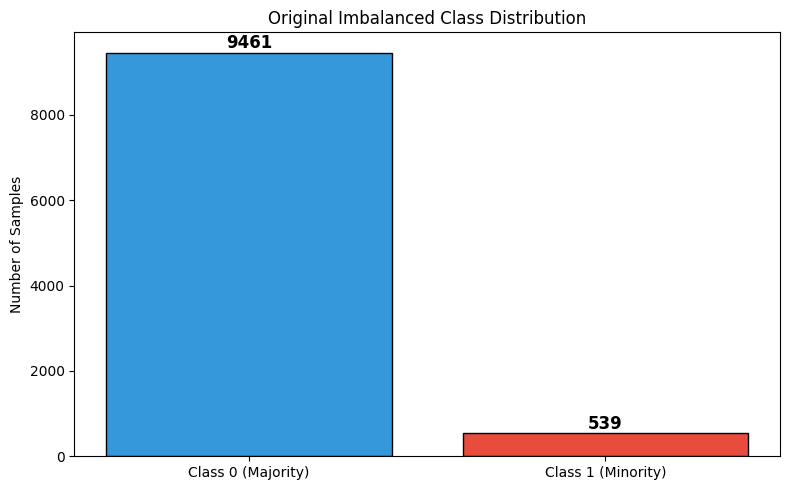

In [24]:
# Create imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],  # 95% class 0, 5% class 1
    random_state=42
)

# Check class distribution
unique, counts = np.unique(y_imb, return_counts=True)

print("IMBALANCED DATASET")
print("=" * 40)
print(f"Total samples: {len(y_imb)}")
print(f"Class 0 (Majority): {counts[0]} ({counts[0]/len(y_imb)*100:.1f}%)")
print(f"Class 1 (Minority): {counts[1]} ({counts[1]/len(y_imb)*100:.1f}%)")
print(f"Imbalance Ratio: {counts[0]/counts[1]:.1f}:1")

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.bar(['Class 0 (Majority)', 'Class 1 (Minority)'], counts,
        color=['#3498db', '#e74c3c'], edgecolor='black')
plt.ylabel('Number of Samples')
plt.title('Original Imbalanced Class Distribution')
for i, count in enumerate(counts):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.1 SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE creates synthetic samples by:
1. Selecting a minority class sample
2. Finding its k nearest neighbors (also minority class)
3. Creating new samples along the line segments connecting the sample to its neighbors

This generates realistic synthetic data rather than just duplicating existing samples.

In [25]:
# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

# Check new distribution
unique_smote, counts_smote = np.unique(y_smote, return_counts=True)

print("AFTER SMOTE")
print("=" * 40)
print(f"Total samples: {len(y_smote)}")
print(f"Class 0: {counts_smote[0]} ({counts_smote[0]/len(y_smote)*100:.1f}%)")
print(f"Class 1: {counts_smote[1]} ({counts_smote[1]/len(y_smote)*100:.1f}%)")
print(f"Synthetic samples added: {counts_smote[1] - counts[1]}")

AFTER SMOTE
Total samples: 18922
Class 0: 9461 (50.0%)
Class 1: 9461 (50.0%)
Synthetic samples added: 8922


## 4.2 ADASYN (Adaptive Synthetic Sampling)

ADASYN improves upon SMOTE by generating more synthetic samples for minority class instances that are harder to learn (those closer to the decision boundary).

In [26]:
# Apply ADASYN
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_imb, y_imb)

# Check new distribution
unique_adasyn, counts_adasyn = np.unique(y_adasyn, return_counts=True)

print("AFTER ADASYN")
print("=" * 40)
print(f"Total samples: {len(y_adasyn)}")
print(f"Class 0: {counts_adasyn[0]} ({counts_adasyn[0]/len(y_adasyn)*100:.1f}%)")
print(f"Class 1: {counts_adasyn[1]} ({counts_adasyn[1]/len(y_adasyn)*100:.1f}%)")
print(f"Synthetic samples added: {counts_adasyn[1] - counts[1]}")

AFTER ADASYN
Total samples: 18857
Class 0: 9461 (50.2%)
Class 1: 9396 (49.8%)
Synthetic samples added: 8857


## 4.3 Borderline-SMOTE

Borderline-SMOTE identifies minority samples near the decision boundary and generates synthetic samples only from these borderline cases, which are often the most informative for classification.

In [27]:
# Apply Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_border, y_border = borderline_smote.fit_resample(X_imb, y_imb)

# Check new distribution
unique_border, counts_border = np.unique(y_border, return_counts=True)

print("AFTER BORDERLINE-SMOTE")
print("=" * 40)
print(f"Total samples: {len(y_border)}")
print(f"Class 0: {counts_border[0]} ({counts_border[0]/len(y_border)*100:.1f}%)")
print(f"Class 1: {counts_border[1]} ({counts_border[1]/len(y_border)*100:.1f}%)")
print(f"Synthetic samples added: {counts_border[1] - counts[1]}")

AFTER BORDERLINE-SMOTE
Total samples: 18922
Class 0: 9461 (50.0%)
Class 1: 9461 (50.0%)
Synthetic samples added: 8922


## 4.4 A/B Test: Impact on Classification Performance

Let's train classifiers on the original imbalanced data vs augmented data and compare their performance, especially on the minority class.

In [28]:
from sklearn.metrics import f1_score, balanced_accuracy_score

def evaluate_augmentation(X, y, name):
    """
    Train a classifier and evaluate on test set.

    Returns:
        dict with accuracy, F1-score, and balanced accuracy
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train Random Forest
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Calculate metrics
    results = {
        'name': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_minority': f1_score(y_test, y_pred, pos_label=1),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred),
    }

    return results


# Evaluate all methods
print("TABULAR AUGMENTATION A/B TEST")
print("=" * 60)

datasets = [
    (X_imb, y_imb, 'Original (Imbalanced)'),
    (X_smote, y_smote, 'SMOTE'),
    (X_adasyn, y_adasyn, 'ADASYN'),
    (X_border, y_border, 'Borderline-SMOTE'),
]

all_results = []
for X, y, name in datasets:
    result = evaluate_augmentation(X, y, name)
    all_results.append(result)
    print(f"\n{name}:")
    print(f"  Accuracy:         {result['accuracy']:.4f}")
    print(f"  F1 (Minority):    {result['f1_minority']:.4f}")
    print(f"  Balanced Acc:     {result['balanced_acc']:.4f}")

TABULAR AUGMENTATION A/B TEST

Original (Imbalanced):
  Accuracy:         0.9610
  F1 (Minority):    0.4348
  Balanced Acc:     0.6389

SMOTE:
  Accuracy:         0.9908
  F1 (Minority):    0.9907
  Balanced Acc:     0.9908

ADASYN:
  Accuracy:         0.9931
  F1 (Minority):    0.9931
  Balanced Acc:     0.9931

Borderline-SMOTE:
  Accuracy:         0.9918
  F1 (Minority):    0.9918
  Balanced Acc:     0.9918


### Visualizing Tabular Augmentation Results

We compare the performance metrics across different augmentation techniques. The key metric for imbalanced data is F1-score for the minority class.

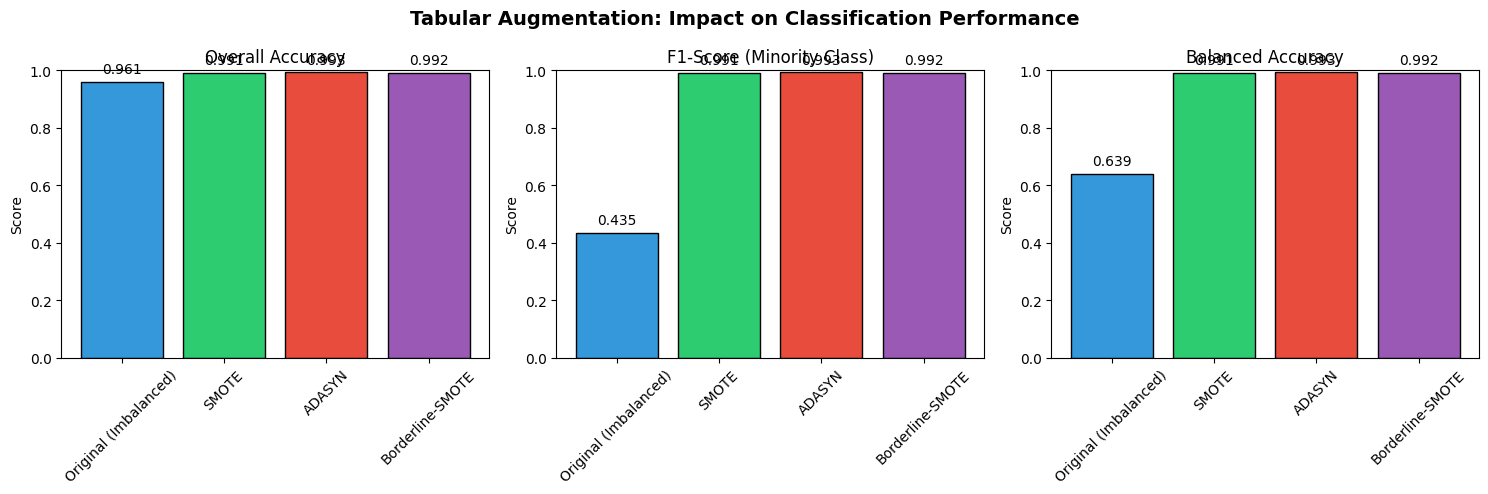


SUMMARY: F1-Score Improvement for Minority Class
SMOTE: +55.59% improvement
ADASYN: +55.83% improvement
Borderline-SMOTE: +55.70% improvement


In [29]:
# Create comparison visualization
results_df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['accuracy', 'f1_minority', 'balanced_acc']
titles = ['Overall Accuracy', 'F1-Score (Minority Class)', 'Balanced Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results_df['name'], results_df[metric], color=colors, edgecolor='black')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Tabular Augmentation: Impact on Classification Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 60)
print("SUMMARY: F1-Score Improvement for Minority Class")
print("=" * 60)
baseline_f1 = results_df[results_df['name'] == 'Original (Imbalanced)']['f1_minority'].values[0]
for _, row in results_df.iterrows():
    if row['name'] != 'Original (Imbalanced)':
        improvement = (row['f1_minority'] - baseline_f1) * 100
        print(f"{row['name']}: {improvement:+.2f}% improvement")

---

# Section 5: Audio Data Augmentation

Audio augmentation is essential for speech recognition, music classification, and sound event detection. We use the **audiomentations** library which provides various audio-specific transformations.

**Common audio augmentations:**
- **Time stretching**: Speed up or slow down without changing pitch
- **Pitch shifting**: Change pitch without changing speed
- **Adding noise**: Background noise, Gaussian noise
- **Time shifting**: Shift audio forward/backward in time
- **Volume changes**: Gain adjustments

---

### Generate Sample Audio Signal

We create a synthetic audio signal combining multiple frequencies to simulate a more realistic audio waveform for demonstration purposes.

Audio signal shape: (44100,)
Sample rate: 22050 Hz
Duration: 2 seconds


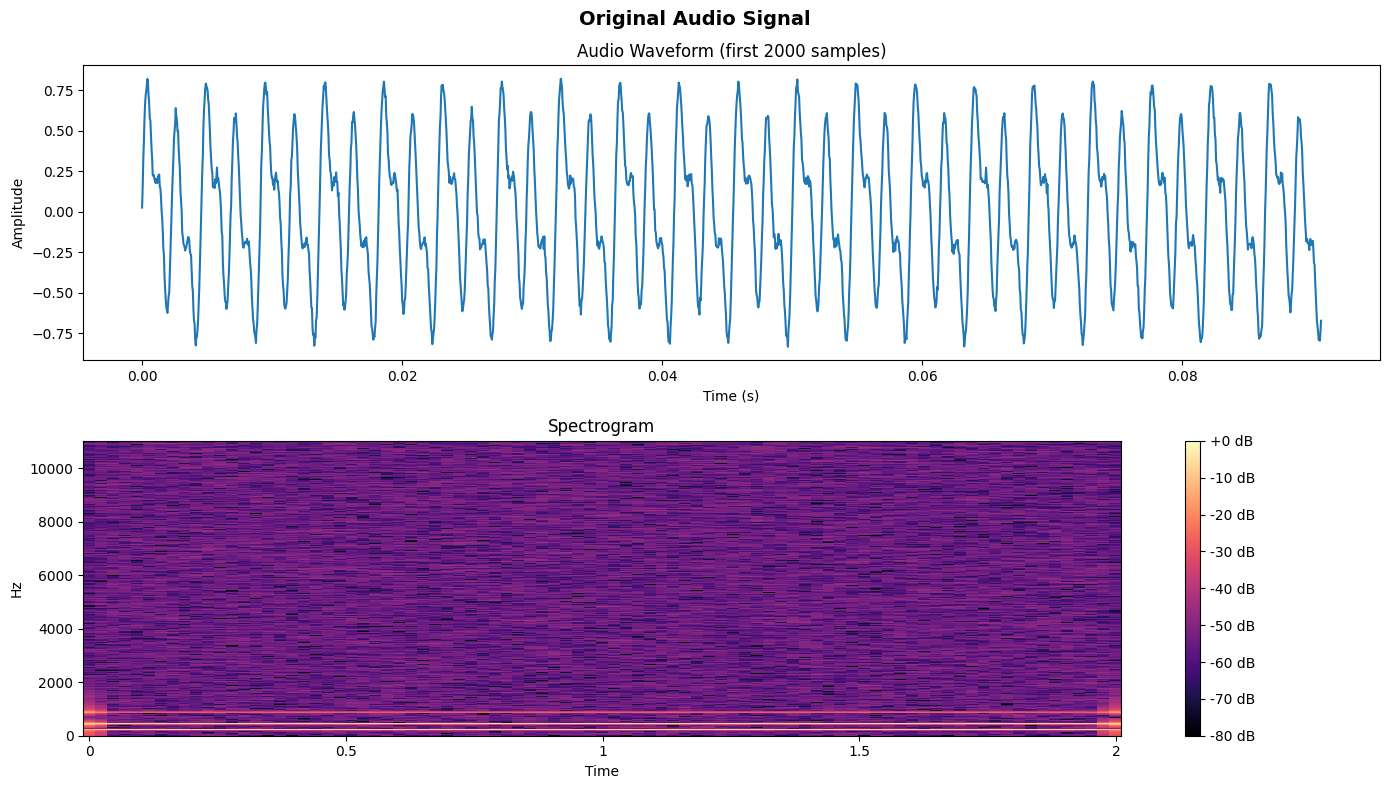

In [30]:
# Generate synthetic audio
sample_rate = 22050  # Standard audio sample rate
duration = 2  # seconds
t_audio = np.linspace(0, duration, int(sample_rate * duration))

# Create a complex waveform (combination of frequencies)
audio_signal = (
    0.5 * np.sin(2 * np.pi * 440 * t_audio) +  # A4 note (440 Hz)
    0.3 * np.sin(2 * np.pi * 880 * t_audio) +  # A5 note (880 Hz)
    0.2 * np.sin(2 * np.pi * 220 * t_audio)    # A3 note (220 Hz)
).astype(np.float32)

# Add slight noise for realism
audio_signal += 0.02 * np.random.randn(len(audio_signal)).astype(np.float32)

print(f"Audio signal shape: {audio_signal.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {duration} seconds")

# Visualize waveform and spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Waveform
axes[0].plot(t_audio[:2000], audio_signal[:2000])
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Audio Waveform (first 2000 samples)')

# Spectrogram
D = librosa.stft(audio_signal)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img = librosa.display.specshow(S_db, sr=sample_rate, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title('Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.suptitle('Original Audio Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.1 Audio Augmentation using Audiomentations

We create an augmentation pipeline using audiomentations library. Each transformation is applied with a specified probability.

In [31]:
# Define audio augmentation pipeline
audio_transform = AA.Compose([
    # Time stretch - speed up or slow down
    AA.TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),

    # Pitch shift - change pitch
    AA.PitchShift(min_semitones=-4, max_semitones=4, p=0.5),

    # Add Gaussian noise
    AA.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),

    # Time shift - shift audio forward/backward
    AA.Shift(min_shift=-0.2, max_shift=0.2, p=0.5),

    # Gain - volume adjustment
    AA.Gain(min_gain_db=-12, max_gain_db=12, p=0.5),
])

print("Audio augmentation pipeline created!")
print("\nTransformations included:")
print("  - TimeStretch (0.8x - 1.2x speed)")
print("  - PitchShift (-4 to +4 semitones)")
print("  - GaussianNoise")
print("  - TimeShift (-20% to +20%)")
print("  - Gain (-12dB to +12dB)")

Audio augmentation pipeline created!

Transformations included:
  - TimeStretch (0.8x - 1.2x speed)
  - PitchShift (-4 to +4 semitones)
  - GaussianNoise
  - TimeShift (-20% to +20%)
  - Gain (-12dB to +12dB)


### Apply and Visualize Audio Augmentations

We apply the augmentation pipeline multiple times and visualize the resulting spectrograms to see how the audio has been modified.

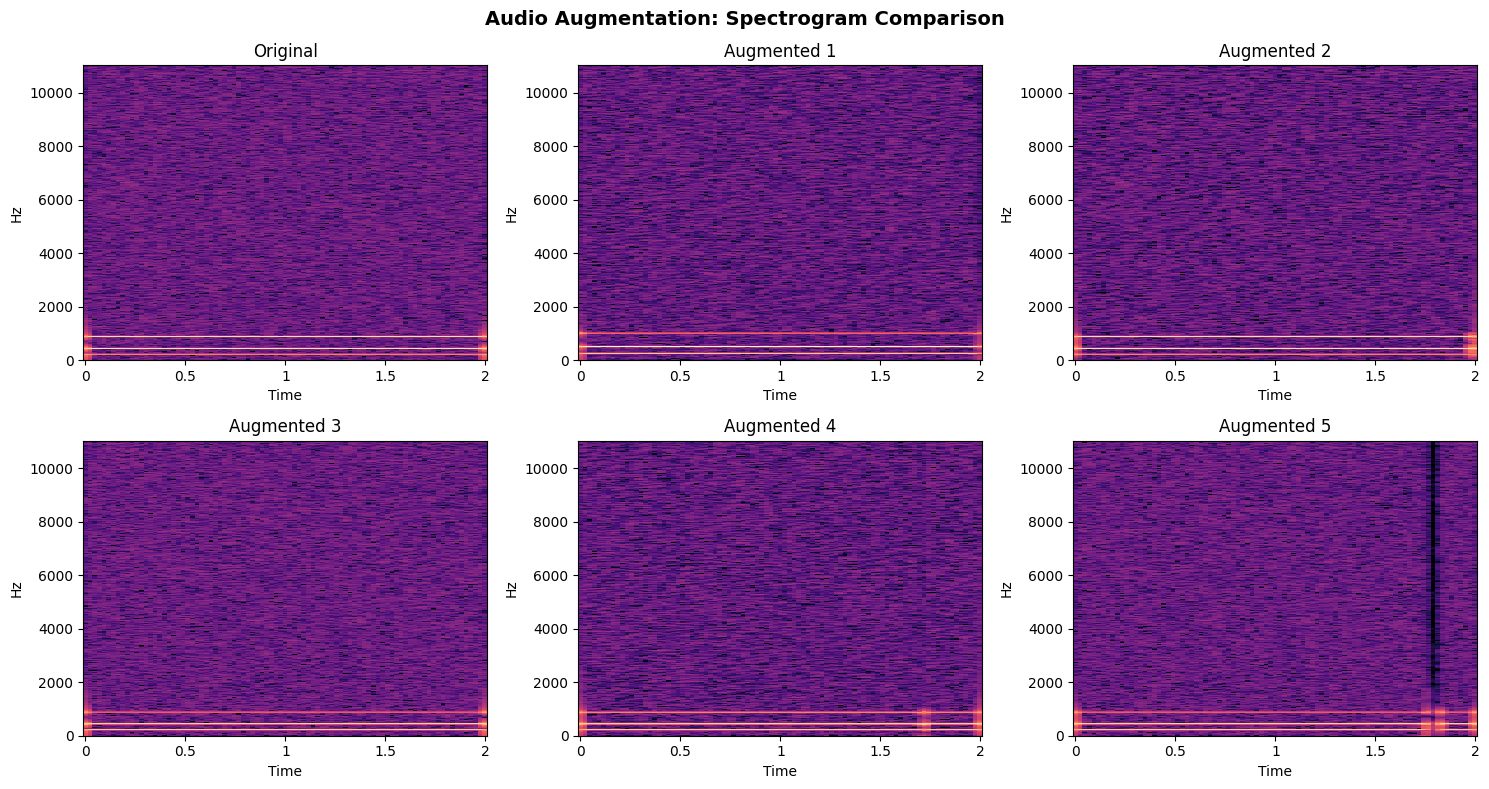

In [32]:
# Apply augmentations and visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original
D_orig = librosa.stft(audio_signal)
S_orig = librosa.amplitude_to_db(np.abs(D_orig), ref=np.max)
librosa.display.specshow(S_orig, sr=sample_rate, x_axis='time', y_axis='hz', ax=axes[0, 0])
axes[0, 0].set_title('Original')

# Apply augmentations
for i, ax in enumerate(axes.flatten()[1:]):
    augmented = audio_transform(samples=audio_signal, sample_rate=sample_rate)
    D_aug = librosa.stft(augmented)
    S_aug = librosa.amplitude_to_db(np.abs(D_aug), ref=np.max)
    librosa.display.specshow(S_aug, sr=sample_rate, x_axis='time', y_axis='hz', ax=ax)
    ax.set_title(f'Augmented {i+1}')

plt.suptitle('Audio Augmentation: Spectrogram Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 Individual Audio Augmentation Effects

Let's apply each augmentation individually to better understand their specific effects on the audio signal.

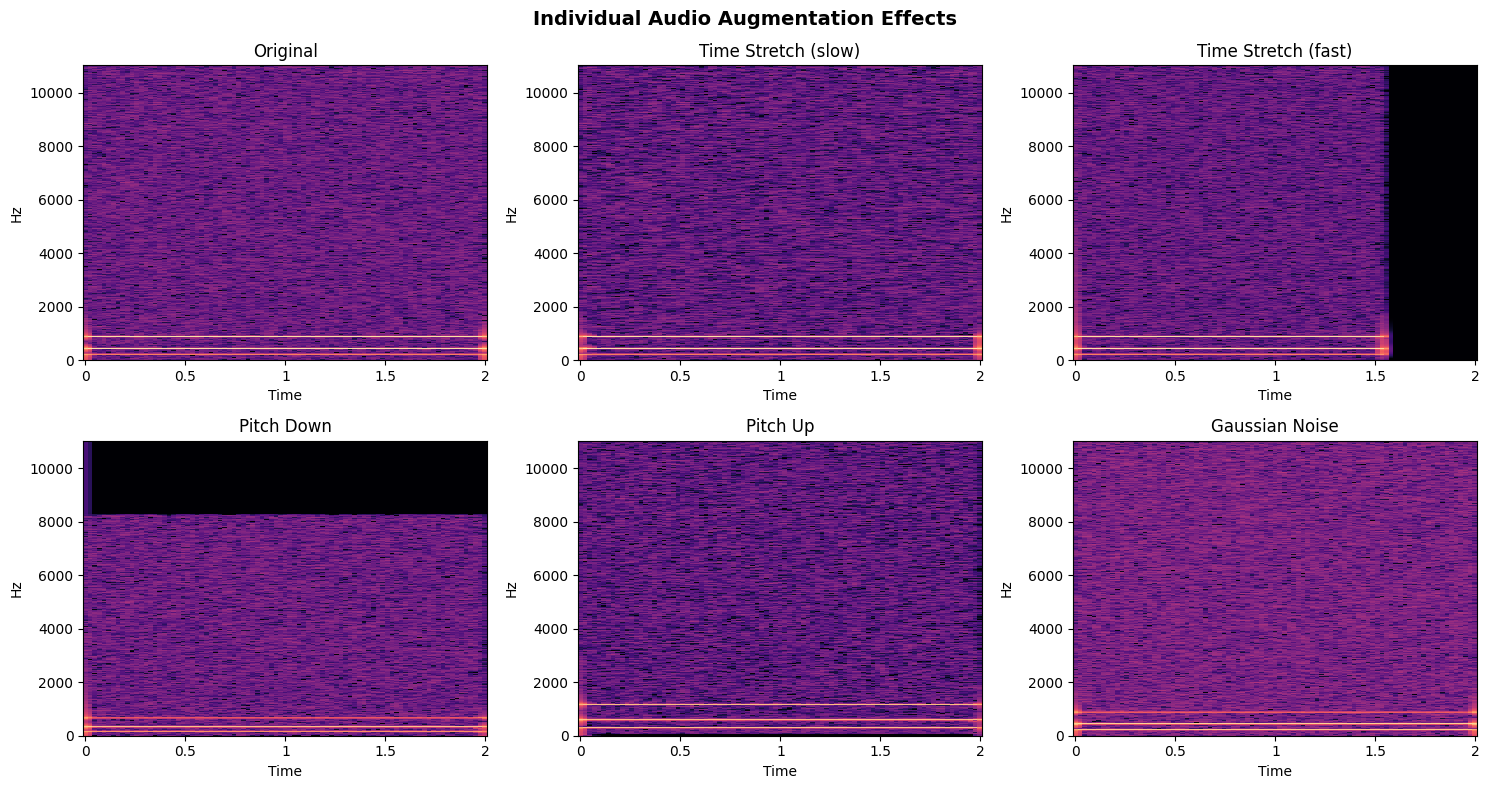

In [33]:
# Individual augmentations
individual_augs = {
    'Original': None,
    'Time Stretch (slow)': AA.TimeStretch(min_rate=0.7, max_rate=0.7, p=1.0),
    'Time Stretch (fast)': AA.TimeStretch(min_rate=1.3, max_rate=1.3, p=1.0),
    'Pitch Down': AA.PitchShift(min_semitones=-5, max_semitones=-5, p=1.0),
    'Pitch Up': AA.PitchShift(min_semitones=5, max_semitones=5, p=1.0),
    'Gaussian Noise': AA.AddGaussianNoise(min_amplitude=0.02, max_amplitude=0.02, p=1.0),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, aug) in enumerate(individual_augs.items()):
    if aug is None:
        signal = audio_signal
    else:
        signal = aug(samples=audio_signal, sample_rate=sample_rate)

    D = librosa.stft(signal)
    S = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    librosa.display.specshow(S, sr=sample_rate, x_axis='time', y_axis='hz', ax=axes[i])
    axes[i].set_title(name)

plt.suptitle('Individual Audio Augmentation Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Section 6: Summary and Best Practices

## Key Takeaways

### Image Augmentation
- Use **Keras preprocessing layers** for simple, GPU-accelerated augmentations
- Use **KerasCV** for advanced techniques like RandAugment, CutMix, and MixUp
- Use **Albumentations** for maximum flexibility and speed

### Text Augmentation
- **Character-level** augmentations simulate real-world noise (typos, OCR errors)
- **Word-level** augmentations (synonyms, swapping) preserve meaning
- **Contextual embeddings** (BERT) produce more natural variations

### Time Series Augmentation
- **Jittering** and **scaling** are simple but effective
- **Time warping** helps with temporal variations
- Preserve the overall pattern while adding realistic variations

### Tabular Augmentation
- **SMOTE** is the go-to technique for class imbalance
- **ADASYN** and **Borderline-SMOTE** may work better for specific cases
- Always evaluate on minority class metrics (F1, balanced accuracy)

### Audio Augmentation
- **Time stretching** and **pitch shifting** create realistic variations
- **Noise injection** improves robustness
- Use spectrograms for visualization and as model input

## Best Practices

1. **Start simple**: Begin with basic augmentations before trying advanced techniques
2. **Validate carefully**: Always check that augmentations don't corrupt label information
3. **Use probability**: Not every augmentation should be applied every time
4. **Monitor performance**: A/B test augmented vs non-augmented training
5. **Domain-specific**: Tailor augmentations to your specific use case

---

In [34]:
# Final summary
print("\n" + "="*70)
print("NOTEBOOK 2: DATA AUGMENTATION SUMMARY")
print("="*70)
print("""
MODALITIES COVERED:
-------------------
1. IMAGE
   - Libraries: keras-cv, albumentations, tf.keras.layers
   - Techniques: RandAugment, CutMix, MixUp, Cutout, geometric, color

2. TEXT
   - Library: nlpaug
   - Techniques: Character, word, and sentence-level augmentations

3. TIME SERIES
   - Custom implementations
   - Techniques: Jittering, scaling, warping, permutation

4. TABULAR
   - Library: imbalanced-learn
   - Techniques: SMOTE, ADASYN, Borderline-SMOTE

5. AUDIO
   - Libraries: audiomentations, librosa
   - Techniques: Time stretch, pitch shift, noise, gain

KEY INSIGHT:
------------
Data augmentation consistently improves model performance across
all modalities by creating realistic variations that help models
generalize better to unseen data.
""")
print("="*70)


NOTEBOOK 2: DATA AUGMENTATION SUMMARY

MODALITIES COVERED:
-------------------
1. IMAGE
   - Libraries: keras-cv, albumentations, tf.keras.layers
   - Techniques: RandAugment, CutMix, MixUp, Cutout, geometric, color

2. TEXT
   - Library: nlpaug
   - Techniques: Character, word, and sentence-level augmentations

3. TIME SERIES
   - Custom implementations
   - Techniques: Jittering, scaling, warping, permutation

4. TABULAR
   - Library: imbalanced-learn
   - Techniques: SMOTE, ADASYN, Borderline-SMOTE

5. AUDIO
   - Libraries: audiomentations, librosa
   - Techniques: Time stretch, pitch shift, noise, gain

KEY INSIGHT:
------------
Data augmentation consistently improves model performance across
all modalities by creating realistic variations that help models
generalize better to unseen data.

